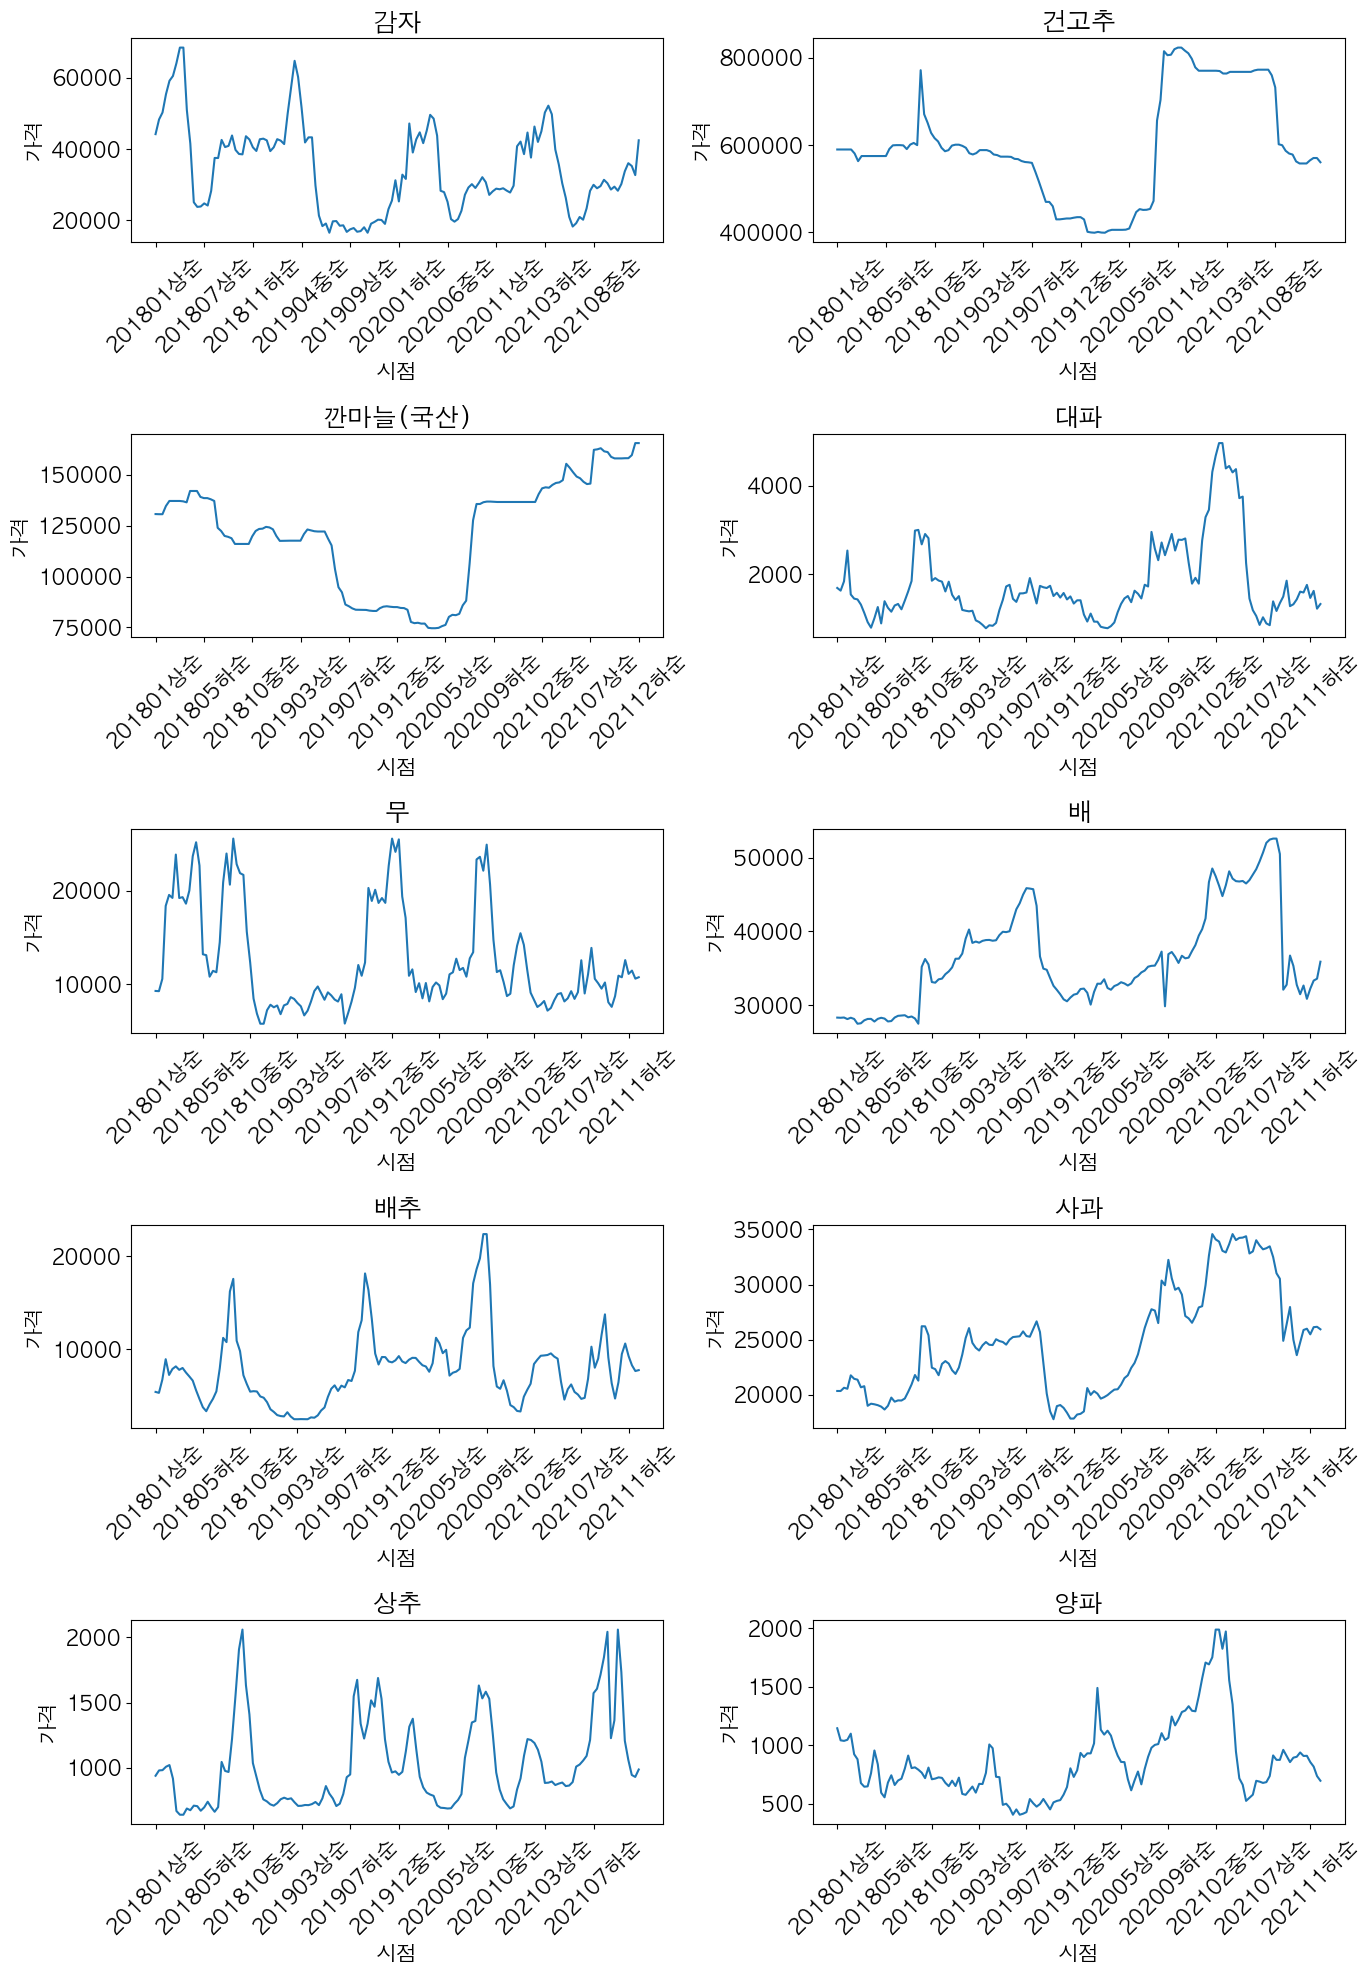

In [25]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib

# -------------------------------
# 1. 데이터 불러오기 (전처리 완료 파일)
# -------------------------------
df = pd.read_csv("train_target_only_cleaned.csv")
df.columns = df.columns.str.strip()

# -------------------------------
# 2. 품목 필터링 (필요하면 유지)
# -------------------------------
targets = [
    ("건고추", "화건", "30 kg", "상품"),
    ("사과", "홍로", "10 개", "상품"),
    ("사과", "후지", "10 개", "상품"),
    ("감자", "감자 수미", "20키로상자", "상"),
    ("배", "신고", "10 개", "상품"),
    ("깐마늘(국산)", "깐마늘(국산)", "20 kg", "상품"),
    ("무", "무", "20키로상자", "상"),
    ("상추", "청", "100 g", "상품"),
    ("배추", "배추", "10키로망대", "상"),
    ("양파", "양파", "1키로", "상"),
    ("대파", "대파(일반)", "1키로단", "상")
]

filtered = []

for item, variety, unit, grade in targets:
    cond = (
        (df["품목명"] == item) &
        (df["품종명"] == variety) &
        (df["거래단위"] == unit) &
        (df["등급"] == grade)
    )
    filtered.append(df[cond])

target_data = pd.concat(filtered)

# -------------------------------
# 3. 정렬 (중요 ⭐)
# -------------------------------
target_data = target_data.sort_values(["품목명", "시점"])

# -------------------------------
# 4. 그래프 설정
# -------------------------------
matplotlib.rcParams['font.family'] = 'AppleGothic'
matplotlib.rcParams['axes.unicode_minus'] = False

items = target_data["품목명"].unique()[:10]

fig, axes = plt.subplots(5, 2, figsize=(14,20))
axes = axes.flatten()

# -------------------------------
# 5. 시계열 시각화 (시점 그대로 사용 ⭐)
# -------------------------------
for i, item in enumerate(items):

    df_item = target_data[target_data["품목명"] == item]

    axes[i].plot(df_item["시점"], df_item["평균가격(원)"])

    axes[i].set_title(item)
    axes[i].set_xlabel("시점")
    axes[i].set_ylabel("가격")

    # ⭐ x축 너무 많아서 일부만 표시
    step = max(len(df_item) // 10, 1)
    axes[i].set_xticks(df_item["시점"][::step])
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# heat map 으로 나타내기

# 마늘 대파 무 배 배추 상추 사과 품목은 여름에 가격이 급등하는 것을 보임!


[품목별 최고가 시기 Top-3]
        품목명  rank   월   순        평균가격(원)
0        감자     1   3  중순   53396.777917
1        감자     2   3  하순   53220.000000
2        감자     3   4  상순   51344.296296
3       건고추     1   2  중순  647375.000000
4       건고추     2   2  상순  646333.333333
5       건고추     3   8  중순  627636.750000
6   깐마늘(국산)     1  11  중순  127753.550000
7   깐마늘(국산)     2  12  하순  126653.675000
8   깐마늘(국산)     3  11  상순  126189.250000
9        대파     1   2  상순    2274.797917
10       대파     2   9  상순    2233.121528
11       대파     3  10  상순    2191.232639
12        무     1   8  하순   17154.725476
13        무     2   9  상순   17007.350694
14        무     3   9  하순   16750.184028
15        배     1   7  하순   40551.500000
16        배     2   8  중순   40543.345000
17        배     3   8  상순   40529.845000
18       배추     1   9  중순   14777.470079
19       배추     2   9  하순   14230.986250
20       배추     3   9  상순   13530.375000
21       사과     1   9  하순   26640.105000
22       사과     2   8  상순   26461.250

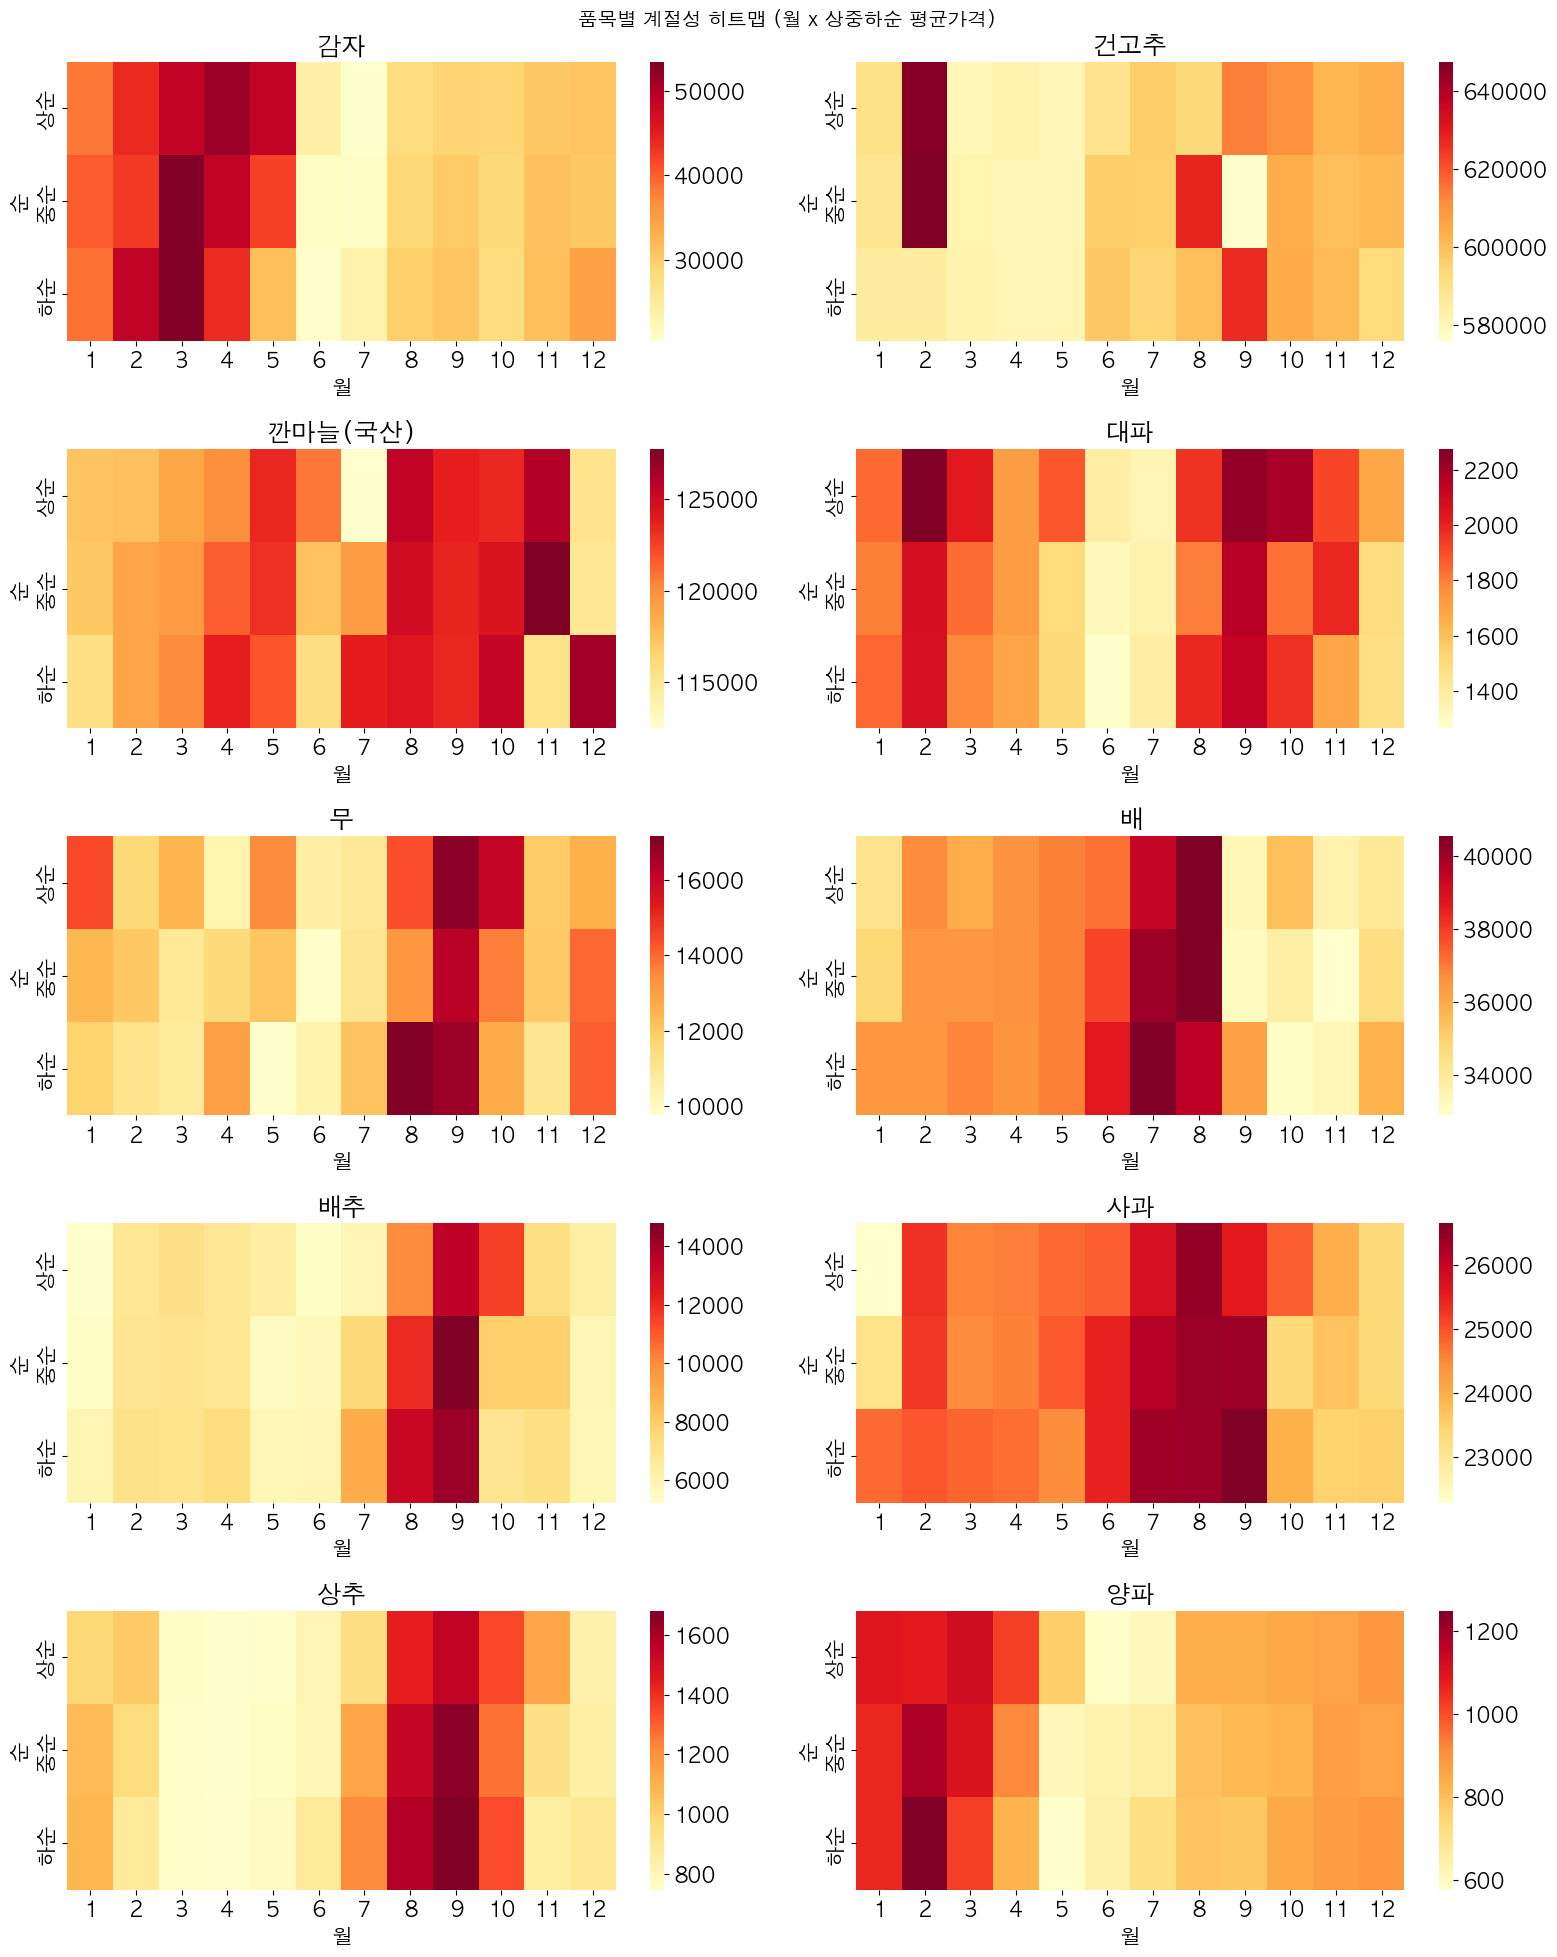

In [30]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib

# -------------------------------
# 0. 한글 폰트 설정 (맥)
# -------------------------------
matplotlib.rcParams["font.family"] = "AppleGothic"
matplotlib.rcParams["axes.unicode_minus"] = False


# -------------------------------
# 1. 데이터 로드
# -------------------------------
train_path = "train_target_only_cleaned.csv" if os.path.exists("train_target_only_cleaned.csv") else "train_target_only_cleaned.csv"
df = pd.read_csv(train_path)


# -------------------------------
# 2. 시점 파싱 (YYYYMM 상/중/하순)
# -------------------------------
raw = df["시점"].astype(str).str.replace(r"\s+", "", regex=True)

# YYYYMM 추출
ym = raw.str.extract(r"(\d{6})")[0]

# 상/중/하순 → 날짜 변환
day = pd.Series(index=df.index, dtype="object")

day[raw.str.contains("상순", na=False)] = "01"
day[raw.str.contains("중순", na=False)] = "11"
day[raw.str.contains("하순", na=False)] = "21"

df["시점"] = pd.to_datetime(ym + day, format="%Y%m%d", errors="coerce")

# 유효 데이터만
valid_df = df.dropna(subset=["시점"]).copy()


# -------------------------------
# 3. 월 + 순 생성
# -------------------------------
day_to_slot = {
    1: "상순",
    11: "중순",
    21: "하순"
}

valid_df["월"] = valid_df["시점"].dt.month
valid_df["순"] = valid_df["시점"].dt.day.map(day_to_slot)

slot_order = ["상순", "중순", "하순"]


# -------------------------------
# 4. 월 x 순 평균가격 계산
# -------------------------------
season_grid = (
    valid_df[valid_df["순"].isin(slot_order)]
    .groupby(["품목명", "월", "순"], as_index=False)["평균가격(원)"]
    .mean()
)


# -------------------------------
# 5. 품목별 최고가 시기 TOP3
# -------------------------------
peak_rows = []

for item, g in season_grid.groupby("품목명"):

    top3 = g.sort_values("평균가격(원)", ascending=False).head(3)

    for rank, (_, row) in enumerate(top3.iterrows(), start=1):
        peak_rows.append({
            "품목명": item,
            "rank": rank,
            "월": int(row["월"]),
            "순": row["순"],
            "평균가격(원)": float(row["평균가격(원)"])
        })

peak_table = pd.DataFrame(peak_rows).sort_values(["품목명", "rank"])

print("\n[품목별 최고가 시기 Top-3]")
print(peak_table)


# -------------------------------
# 6. 히트맵 시각화
# -------------------------------
items = sorted(season_grid["품목명"].unique())

if items:

    ncols = 2
    nrows = int(np.ceil(len(items) / ncols))

    fig, axes = plt.subplots(
        nrows,
        ncols,
        figsize=(16, 4 * nrows)
    )

    axes = np.array(axes).reshape(-1)

    for i, item in enumerate(items):

        mat = (
            season_grid[season_grid["품목명"] == item]
            .pivot(index="순", columns="월", values="평균가격(원)")
            .reindex(slot_order)
            .reindex(columns=list(range(1, 13)))
        )

        sns.heatmap(
            mat,
            cmap="YlOrRd",
            ax=axes[i],
            cbar=True
        )

        axes[i].set_title(item)
        axes[i].set_xlabel("월")
        axes[i].set_ylabel("순")

    # 남는 subplot 제거
    for j in range(i + 1, len(axes)):
        axes[j].axis("off")

    fig.suptitle(
        "품목별 계절성 히트맵 (월 x 상중하순 평균가격)",
        fontsize=14
    )

    plt.tight_layout()
    plt.show()

else:
    print("시각화할 품목 데이터가 없습니다.")

# 계절성을 위한 4년치 월별 평균

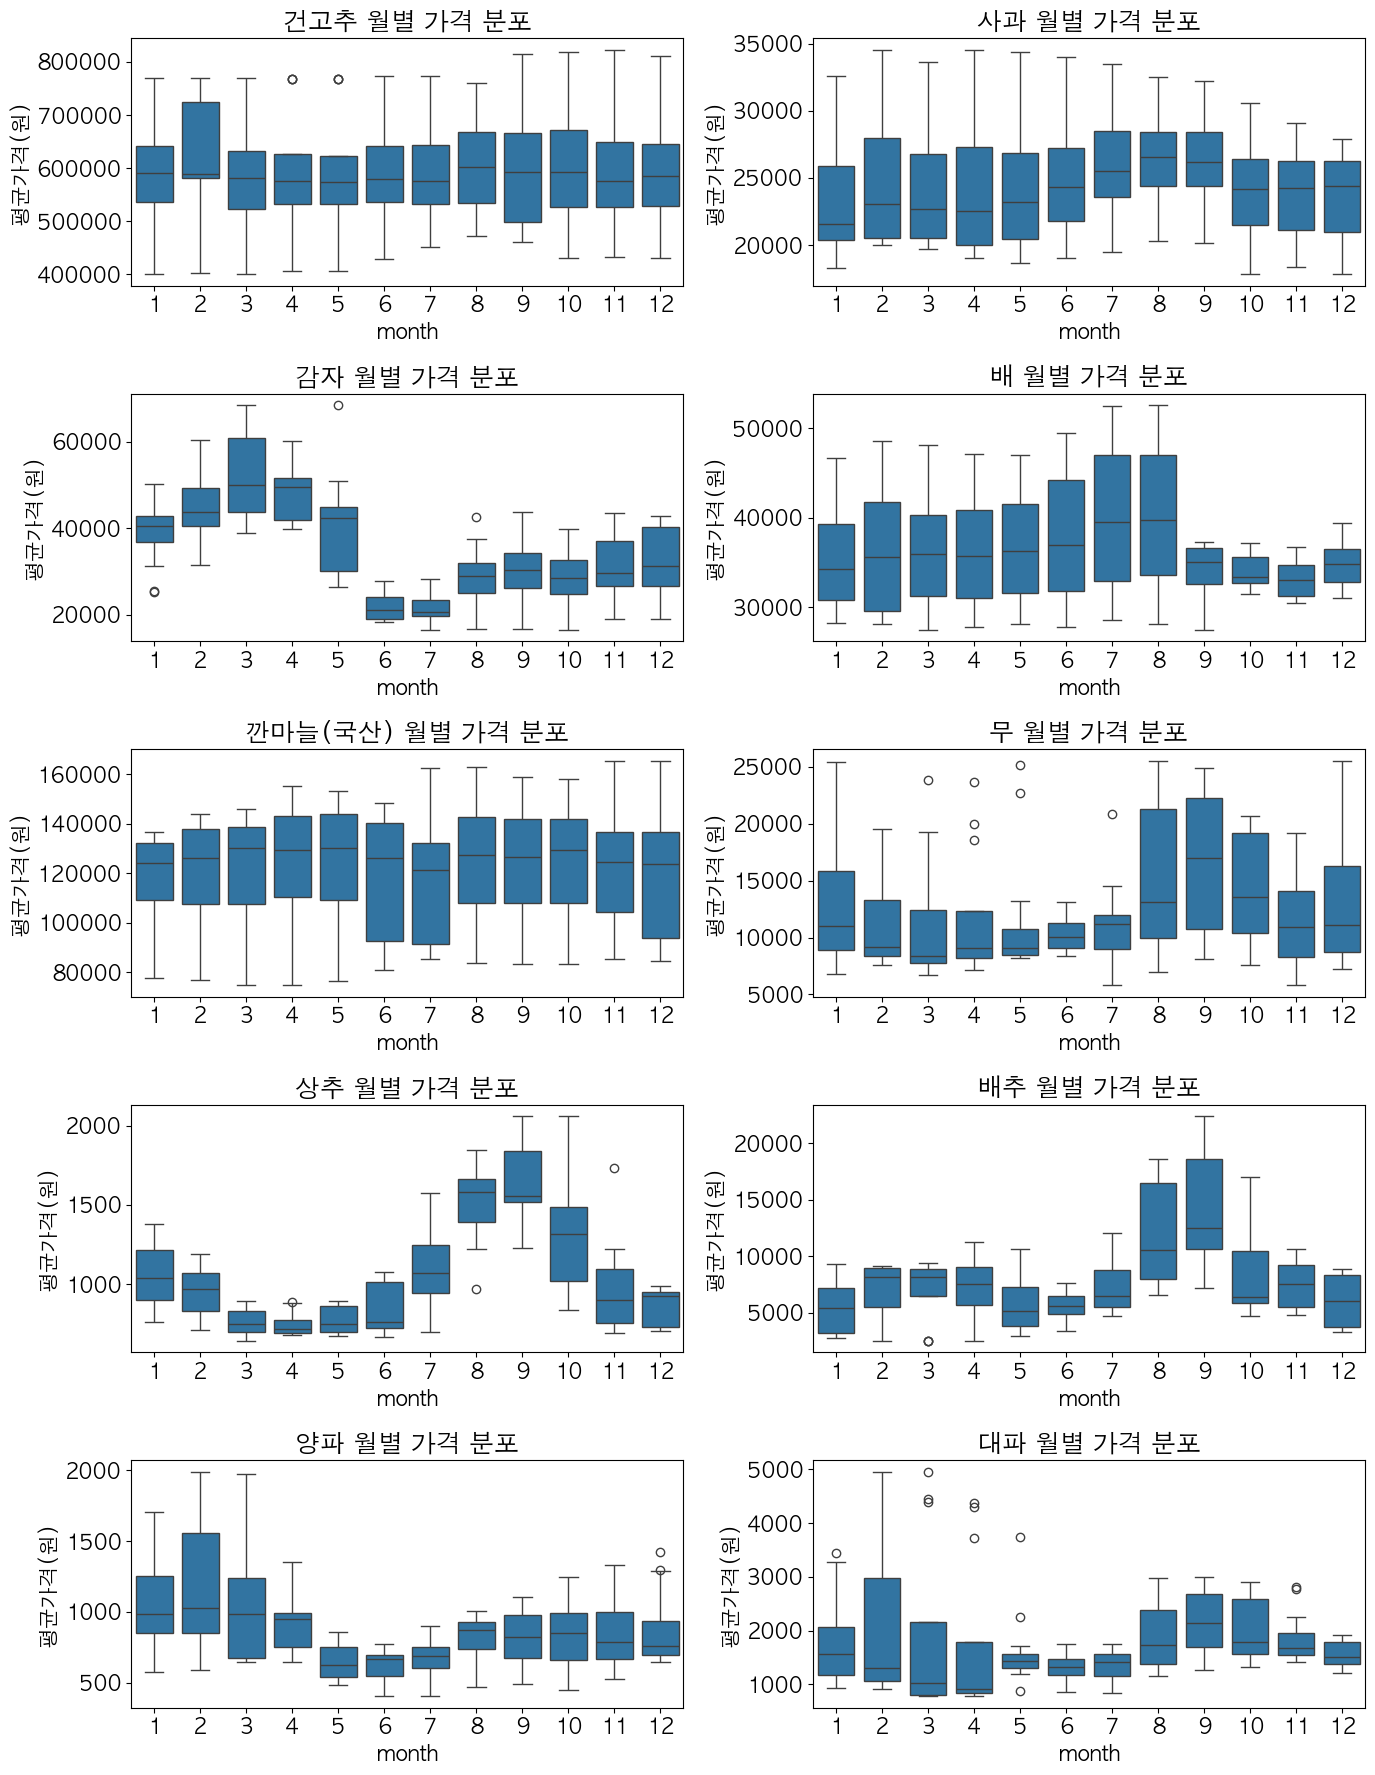

In [5]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# ⭐ 파일 불러오기
target_data = pd.read_csv("train_target_only_cleaned.csv")

# ⭐ month 생성
target_data['month'] = target_data['시점'].astype(str).str[:6].str[4:6].astype(int)

items = target_data['품목명'].unique()

fig, axes = plt.subplots(5,2,figsize=(14,18))
axes = axes.flatten()

for i, item in enumerate(items):

    data = target_data[target_data['품목명'] == item]

    sns.boxplot(
        data=data,
        x='month',
        y='평균가격(원)',
        ax=axes[i]
    )

    axes[i].set_title(item + " 월별 가격 분포")

plt.tight_layout()
plt.show()

# 품목별 가격 변동계수
어떤 품목이 가격 변동이 심한지
심한 것 끼리 묶어서 분석 할 수 있지 않을까..

       품목명           mean            std        CV
3       대파    1781.265776     927.276840  0.520572
6       배추    7809.816169    3968.819365  0.508183
4        무   12653.465557    5494.638983  0.434240
9       양파     865.788913     331.554032  0.382950
0       감자   34466.756763   12284.021352  0.356402
8       상추    1028.621571     343.651602  0.334089
2  깐마늘(국산)  121006.732151   26871.878343  0.222069
1      건고추  596514.157143  124637.054662  0.208942
7       사과   24805.530278    4826.861144  0.194588
5        배   36351.796111    6716.870770  0.184774


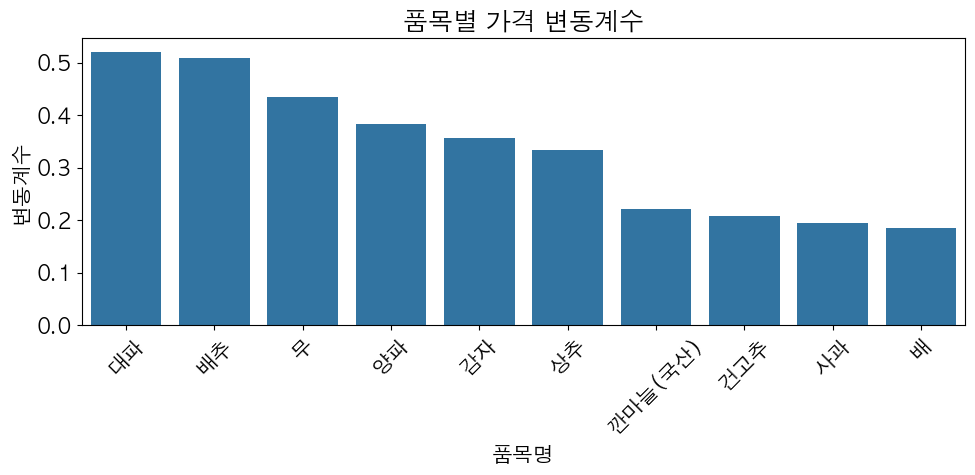

In [32]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib

# -------------------------------
# 1. 데이터 불러오기
# -------------------------------
df = pd.read_csv("train_target_only_cleaned.csv")
df.columns = df.columns.str.strip()

# -------------------------------
# 2. 품목 필터링
# -------------------------------
targets = [
    ("건고추", "화건", "30 kg", "상품"),
    ("사과", "홍로", "10 개", "상품"),
    ("사과", "후지", "10 개", "상품"),
    ("감자", "감자 수미", "20키로상자", "상"),
    ("배", "신고", "10 개", "상품"),
    ("깐마늘(국산)", "깐마늘(국산)", "20 kg", "상품"),
    ("무", "무", "20키로상자", "상"),
    ("상추", "청", "100 g", "상품"),
    ("배추", "배추", "10키로망대", "상"),
    ("양파", "양파", "1키로", "상"),
    ("대파", "대파(일반)", "1키로단", "상")
]

filtered = []

for item, variety, unit, grade in targets:
    cond = (
        (df["품목명"] == item) &
        (df["품종명"] == variety) &
        (df["거래단위"] == unit) &
        (df["등급"] == grade)
    )
    filtered.append(df[cond])

target_data = pd.concat(filtered)

# -------------------------------
# 3. 변동계수(CV) 계산
# -------------------------------
price_col = "평균가격(원)"

cv_df = target_data.groupby("품목명")[price_col].agg(
    mean="mean",
    std="std"
).reset_index()

cv_df["CV"] = cv_df["std"] / cv_df["mean"]

# 변동성 큰 순으로 정렬
cv_df = cv_df.sort_values("CV", ascending=False)

print(cv_df)

# -------------------------------
# 4. 그래프 시각화
# -------------------------------
matplotlib.rcParams['font.family'] = 'AppleGothic'
matplotlib.rcParams['axes.unicode_minus'] = False

plt.figure(figsize=(10,5))

sns.barplot(
    data=cv_df,
    x="품목명",
    y="CV"
)

plt.xticks(rotation=45)
plt.title("품목별 가격 변동계수")
plt.ylabel("변동계수")

plt.tight_layout()
plt.show()

# 여름에 가격이 급등하는 것을 보여주는 ...

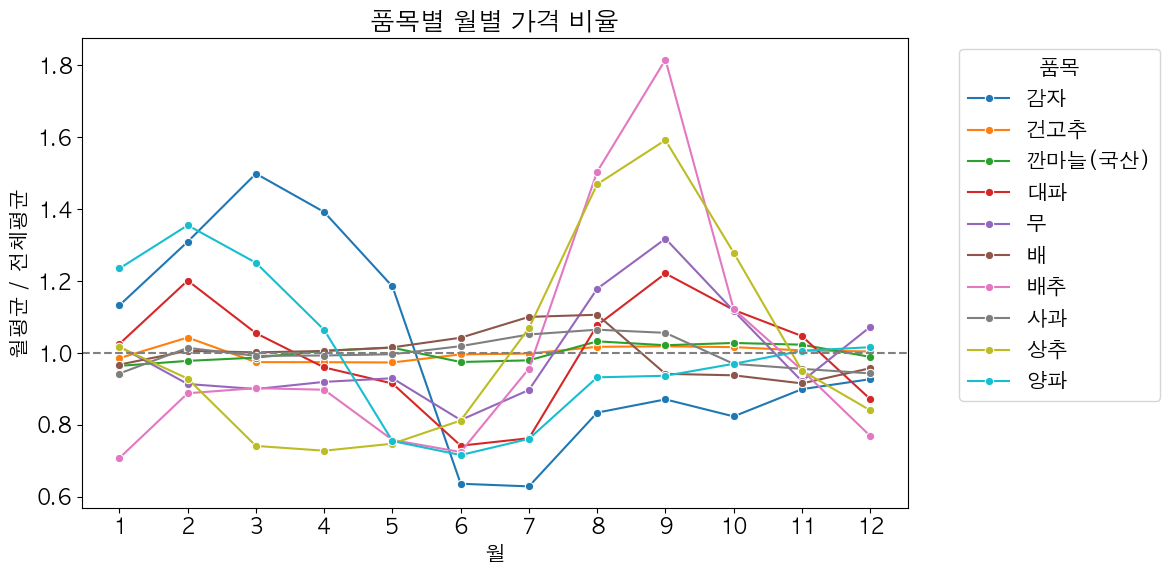

In [24]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib

# -------------------------------
# 1. 데이터 불러오기
# -------------------------------
df = pd.read_csv("train_target_only_cleaned.csv")
df.columns = df.columns.str.strip()

# -------------------------------
# 2. 품목 필터링
# -------------------------------
targets = [
    ("건고추", "화건", "30 kg", "상품"),
    ("사과", "홍로", "10 개", "상품"),
    ("사과", "후지", "10 개", "상품"),
    ("감자", "감자 수미", "20키로상자", "상"),
    ("배", "신고", "10 개", "상품"),
    ("깐마늘(국산)", "깐마늘(국산)", "20 kg", "상품"),
    ("무", "무", "20키로상자", "상"),
    ("상추", "청", "100 g", "상품"),
    ("배추", "배추", "10키로망대", "상"),
    ("양파", "양파", "1키로", "상"),
    ("대파", "대파(일반)", "1키로단", "상")
]

filtered = []
for item, variety, unit, grade in targets:
    cond = (
        (df["품목명"] == item) &
        (df["품종명"] == variety) &
        (df["거래단위"] == unit) &
        (df["등급"] == grade)
    )
    filtered.append(df[cond])

target_data = pd.concat(filtered)

# -------------------------------
# 3. month 생성
# -------------------------------
target_data["month"] = target_data["시점"].astype(str).str[4:6].astype(int)

price_col = "평균가격(원)"

# -------------------------------
# 4. 월별 평균
# -------------------------------
monthly = target_data.groupby(["품목명","month"])[price_col].mean().reset_index()

# -------------------------------
# 5. 전체 평균
# -------------------------------
overall = target_data.groupby("품목명")[price_col].mean().reset_index()
overall = overall.rename(columns={price_col: "overall_mean"})

# -------------------------------
# 6. merge + 비율 계산
# -------------------------------
df_ratio = pd.merge(monthly, overall, on="품목명")

df_ratio["ratio"] = df_ratio[price_col] / df_ratio["overall_mean"]

# -------------------------------
# 7. 그래프
# -------------------------------
matplotlib.rcParams['font.family'] = 'AppleGothic'
matplotlib.rcParams['axes.unicode_minus'] = False

plt.figure(figsize=(12,6))

sns.lineplot(
    data=df_ratio,
    x="month",
    y="ratio",
    hue="품목명",
    marker="o"
)

plt.axhline(1, linestyle="--", color="gray")

plt.title("품목별 월별 가격 비율")
plt.xlabel("월")
plt.ylabel("월평균 / 전체평균")

plt.xticks(range(1,13))

# ⭐ 핵심 수정
plt.legend(
    title="품목",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()